In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

In [4]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


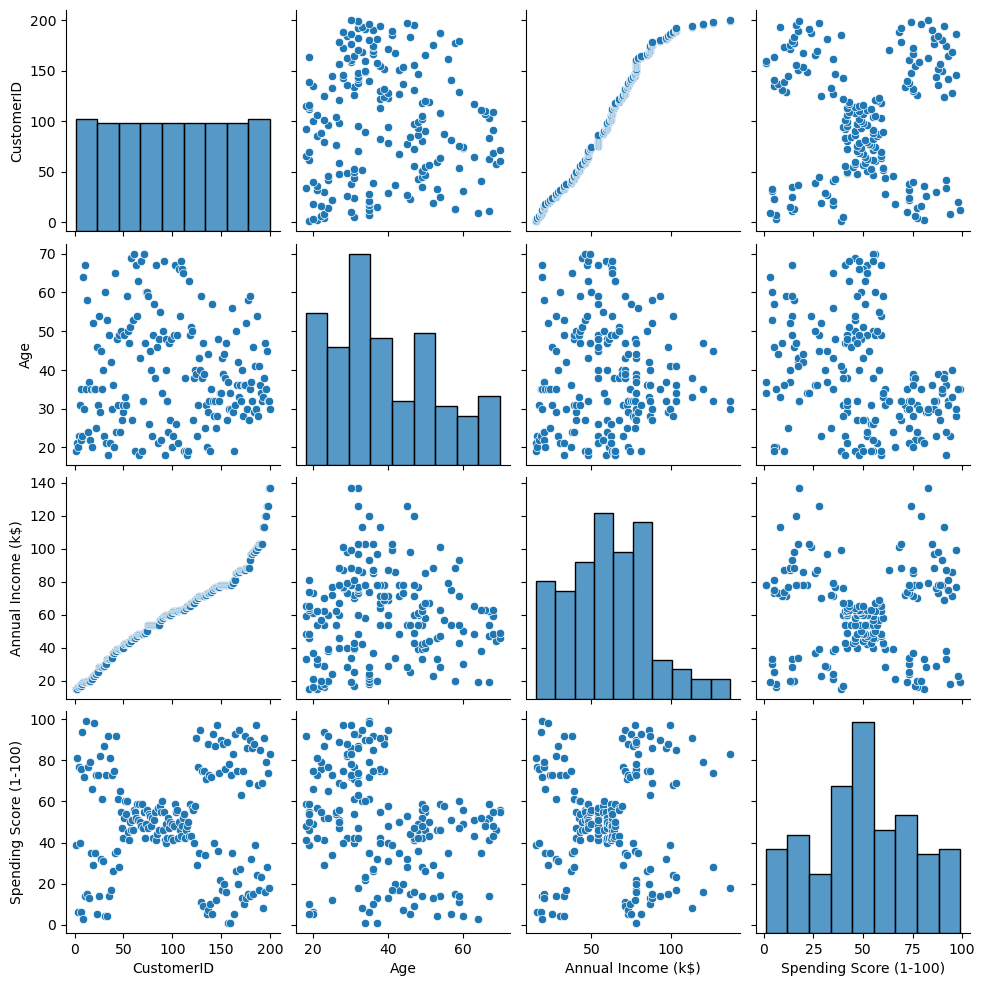

In [5]:
# explore dataset

df.info()
df.describe()
df.isnull().sum()
sns.pairplot(df)
plt.show()

In [9]:
# select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [10]:
# feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

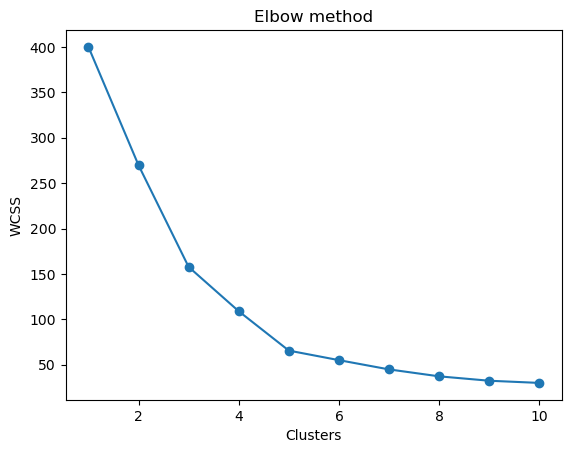

In [11]:
# elbow method

wcss = []

for i in range (1,11):
    model = KMeans(
        n_clusters = i,
        random_state = 42,
        n_init = 10
    )

    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow method")
plt.show()

In [12]:
# Train model

kmeans = KMeans(
    n_clusters = 5,
    random_state = 42,
    n_init = 10
)

clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [13]:
# Evaluate Method

score = silhouette_score(X_scaled, clusters)
print(score)

0.5546571631111091


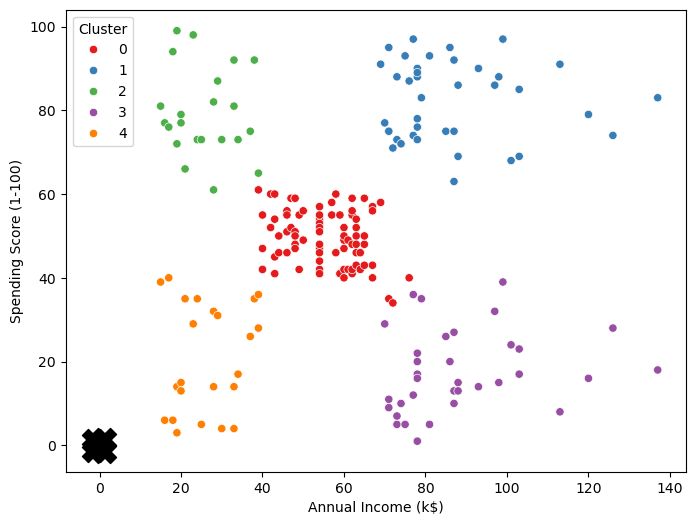

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(

x=df['Annual Income (k$)'],
y=df['Spending Score (1-100)'],
hue=df['Cluster'],
palette='Set1'

)

plt.scatter(

kmeans.cluster_centers_[:,0],
kmeans.cluster_centers_[:,1],
color='black',
s=300,
marker='X'

)

plt.show()

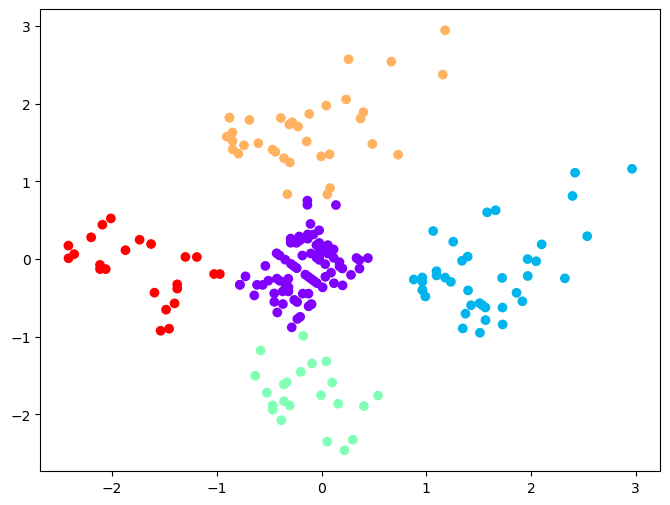

In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(

X_pca[:,0],
X_pca[:,1],
c=clusters,
cmap='rainbow'

)

plt.show()

In [25]:

# Save the KMeans model
joblib.dump(kmeans, "K_means_clustering_model.pkl")

# Save the scaler
joblib.dump(scaler, "K_means_clustering_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [26]:

# Load model and scaler
model = joblib.load("K_means_clustering_model.pkl")
scaler = joblib.load("K_means_clustering_scaler.pkl")

# New customer data as a DataFrame
new_customer = pd.DataFrame({
    'Annual Income (k$)': [70],
    'Spending Score (1-100)': [65]
})

# Scale the input
new_scaled = scaler.transform(new_customer)

# Predict cluster
cluster = model.predict(new_scaled)

print(f"The customer belongs to Cluster {cluster[0]}")

The customer belongs to Cluster 0
